# 03 — Features, and Whether They Survive the Test Set

**What this notebook establishes:** why the feature layer looks the way it does, which
features the model actually uses, and — the part that matters most for a model that will
be scored on unseen data — which of them **transfer**.

The interesting result is at the end: the most predictive features turn out to be the most
transferable ones. That is not a coincidence, and the reason is design, not luck.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, "..")
from pathlib import Path as _P

import matplotlib.pyplot as plt
import pandas as pd

from src.config import load_config
from src.features.common import windows

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})
pd.set_option("display.width", 140)

cfg = load_config()
MODELS = _P(cfg.paths.data_root) / "models" / "current"
FEATURES = _P(cfg.paths.features)

shap = pd.read_csv(MODELS / "shap_global.csv")
drift = pd.read_csv(FEATURES / "drift_report.csv")
print(f"{len(shap)} features with SHAP importance, {len(drift)} with a drift measurement")

294 features with SHAP importance, 294 with a drift measurement


---
## 1. The constraint that shaped everything

There is **no symbol or instrument column** anywhere in this dataset. Each `sample_id` is a
self-contained, anonymous observation window.

That single fact removes an entire category of features. There is no "this instrument's
volatility yesterday", no cross-sample state, no classic rolling window over a time series
— because there is no series to roll over. The problem collapses to tabular regression
over 1,257,637 independent rows.

So "rolling" here means something different: **nested time slices inside a sample's own
lookback window**, with the window length differing per table (notebook 01).

In [2]:
for tbl in ("market", "order", "transaction"):
    ws = windows(tbl)
    full = cfg.window.seconds[tbl]
    print(f"{tbl:12s} window {full:5.0f} s   nested: {[f'{w:g}s' for w in ws]}")
print()
print("A feature such as ord_ofi_5s is order-flow imbalance over the last 5 seconds")
print("OF THAT SAMPLE. The ratio of a short window to a long one becomes the")
print("acceleration signal - e.g. ord_event_accel_5s_vs_60s.")

market       window   600 s   nested: ['5s', '10s', '30s', '60s', '120s', '300s', '600s']
order        window    60 s   nested: ['1s', '5s', '10s', '30s', '60s']
transaction  window    60 s   nested: ['1s', '5s', '10s', '30s', '60s']

A feature such as ord_ofi_5s is order-flow imbalance over the last 5 seconds
OF THAT SAMPLE. The ratio of a short window to a long one becomes the
acceleration signal - e.g. ord_event_accel_5s_vs_60s.


### The three families

| Prefix | Source | What it measures |
|---|---|---|
| `mkt_` | L2 book snapshots, 600 s | spread, depth imbalance, microprice edge, realised volatility, book slope |
| `ord_` | order events, 60 s | arrival and cancellation rates, order-flow imbalance, size distribution, time-decayed pressure |
| `txn_` | executed trades, 60 s | signed volume imbalance, trade intensity, VWAP, price momentum |

In [3]:
fam = shap.groupby("family").agg(n_features=("feature", "size"),
                                 shap_share=("share", "sum")).sort_values("shap_share",
                                                                          ascending=False)
fam["shap_share_pct"] = (fam.shap_share * 100).round(1)
fam[["n_features", "shap_share_pct"]]

,n_features,shap_share_pct
family,,
mkt,159,41.6
ord,82,32.7
txn,53,25.7


---
## 2. What the model actually uses

TreeSHAP over the hold-out months, so this reflects signal the model *generalises* rather
than signal it memorised.

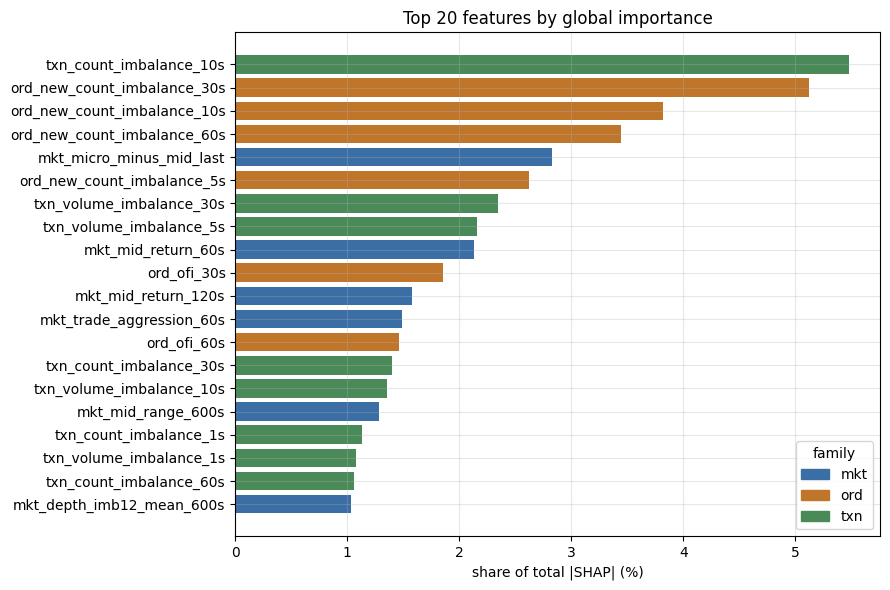

In [4]:
top = shap.head(20).iloc[::-1]
colors = {"mkt": "#3b6ea5", "ord": "#c0762a", "txn": "#4a8a58"}
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.feature, top.share * 100, color=[colors[f] for f in top.family])
ax.set_xlabel("share of total |SHAP| (%)")
ax.set_title("Top 20 features by global importance")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), title="family", loc="lower right")
plt.tight_layout(); plt.show()

The ranking is dominated by **imbalance** features — trade count imbalance, new-order count
imbalance, and the microprice edge over the mid.

This is what market microstructure theory predicts. Order-flow imbalance is the canonical
short-horizon return predictor, and the microprice (the mid weighted by the opposite side's
volume) is the textbook estimate of where the true price sits between the quotes. Seeing
them at the top is a sanity check on the whole feature layer: had raw volumes or price
levels dominated instead, it would have suggested the model was latching onto something
spurious.

In [5]:
kinds = {
    "imbalance / OFI": shap.feature.str.contains("imbalance|_ofi_"),
    "return / momentum": shap.feature.str.contains("return|accel|momentum"),
    "spread": shap.feature.str.contains("spread"),
    "depth": shap.feature.str.contains("depth"),
    "rate / intensity / count": shap.feature.str.contains("rate|intensity|n_total|n_snapshots"),
    "last snapshot": shap.feature.str.endswith("_last"),
}
rows = [{"kind": k, "n": int(m.sum()), "shap_share_pct": round(shap.loc[m, "share"].sum()*100, 1)}
        for k, m in kinds.items()]
pd.DataFrame(rows).sort_values("shap_share_pct", ascending=False).reset_index(drop=True)

,kind,n,shap_share_pct
0,imbalance / OFI,41,42.2
1,rate / intensity / count,53,8.7
2,depth,38,8.1
3,return / momentum,22,7.3
4,last snapshot,11,5.6
5,spread,19,1.8


---
## 3. Does any of it survive the test set?

The training and test periods are not the same market. Notebook 01 established the raw
event densities differ; here the question is whether the *features* differ.

The metric is a standardised mean difference — an effect size, not a p-value:

$$\text{shift} = \frac{|\mu_{test} - \mu_{train}|}{\sigma_{train}}$$

At 1.26M versus 648k samples, any test of "are these distributions identical" returns a
vanishing p-value for a difference far too small to matter. Effect size answers the
question that is actually useful. Conventional reading: < 0.1 negligible, 0.1–0.3 small,
0.3–0.5 moderate, > 0.5 large.

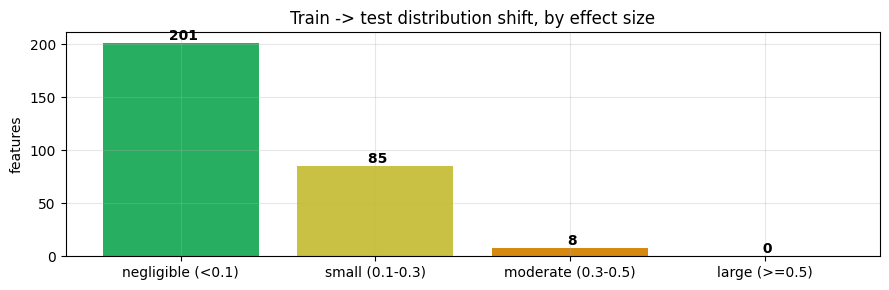

median shift 0.0275 | max 0.3476 | not one feature shifts 'large'


In [6]:
s = drift["shift"].dropna()
buckets = pd.Series({
    "negligible (<0.1)": (s < 0.1).sum(),
    "small (0.1-0.3)": ((s >= 0.1) & (s < 0.3)).sum(),
    "moderate (0.3-0.5)": ((s >= 0.3) & (s < 0.5)).sum(),
    "large (>=0.5)": (s >= 0.5).sum(),
})
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(buckets.index, buckets.values,
       color=["#27ae60", "#c9c144", "#d68910", "#c0392b"])
for i, v in enumerate(buckets.values):
    ax.text(i, v, f" {v}", ha="center", va="bottom", weight="bold")
ax.set_ylabel("features"); ax.set_title("Train -> test distribution shift, by effect size")
plt.tight_layout(); plt.show()

print(f"median shift {s.median():.4f} | max {s.max():.4f} | not one feature shifts 'large'")

### The split that matters

The aggregate looks reassuring, but the average hides the structure. Grouping by *what kind
of quantity a feature is* makes the picture much sharper.

In [7]:
kind_masks = {
    "imbalance / OFI (scale-free)": drift.feature.str.contains("imbalance|_ofi_"),
    "return (scale-free)": drift.feature.str.contains("return"),
    "depth": drift.feature.str.contains("depth"),
    "last snapshot": drift.feature.str.endswith("_last"),
    "spread": drift.feature.str.contains("spread"),
    "rate / intensity / count": drift.feature.str.contains("rate|intensity|n_total"),
}
rows = []
for k, m in kind_masks.items():
    v = drift.loc[m, "shift"].dropna()
    if len(v):
        rows.append({"kind": k, "n": len(v), "median_shift": round(v.median(), 4),
                     "max_shift": round(v.max(), 4)})
tbl = pd.DataFrame(rows).sort_values("median_shift").reset_index(drop=True)
tbl

,kind,n,median_shift,max_shift
0,return (scale-free),8,0.0023,0.0049
1,imbalance / OFI (scale-free),41,0.0053,0.0285
2,last snapshot,11,0.0214,0.2512
3,depth,38,0.0277,0.0654
4,rate / intensity / count,52,0.1769,0.3476
5,spread,19,0.2597,0.2726


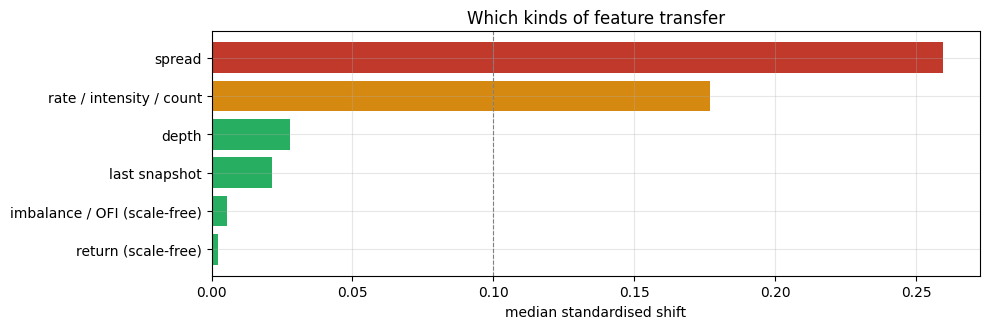

Scale-free quantities barely move. Rates and counts move an order of magnitude more.


In [8]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.barh(tbl.kind, tbl.median_shift,
        color=["#27ae60" if v < 0.05 else "#d68910" if v < 0.2 else "#c0392b"
               for v in tbl.median_shift])
ax.set_xlabel("median standardised shift"); ax.set_title("Which kinds of feature transfer")
ax.axvline(0.1, color="grey", ls="--", lw=.8)
plt.tight_layout(); plt.show()

print("Scale-free quantities barely move. Rates and counts move an order of magnitude more.")

### Why, in one line

The test period is a **more liquid market**. Everything that counts events goes up;
everything that measures the *balance* between two counts stays put — because a ratio
divides the density out.

In [9]:
probe = ["ord_event_rate_60s", "mkt_trade_count_rate_600s", "txn_intensity_60s",
         "mkt_total_depth_mean_600s", "mkt_spread_mean_clean", "mkt_mid_std_600s",
         "ord_ofi_60s", "txn_volume_imbalance_60s", "mkt_depth_imb1_last"]
d = drift.set_index("feature").loc[probe, ["train_mean", "test_mean", "shift"]].copy()
d["test_over_train"] = (d.test_mean / d.train_mean).round(3)
d.round(6)

,train_mean,test_mean,shift,test_over_train
feature,,,,
ord_event_rate_60s,2.253652e+00,3.073160e+00,0.347606,1.364
mkt_trade_count_rate_600s,1.441034e+00,1.951444e+00,0.330432,1.354
txn_intensity_60s,1.377852e+00,1.824094e+00,0.268101,1.324
mkt_total_depth_mean_600s,1.170117e+06,1.452415e+06,0.031014,1.241
mkt_spread_mean_clean,1.267000e-03,1.017000e-03,0.272561,0.802
mkt_mid_std_600s,1.309000e-03,1.193000e-03,0.108169,0.912
ord_ofi_60s,-6.163000e-03,-7.771000e-03,0.004786,1.261
txn_volume_imbalance_60s,-5.991700e-02,-6.757900e-02,0.013433,1.128
mkt_depth_imb1_last,3.326400e-02,3.898900e-02,0.009727,1.172


Order events ×1.36, trade count ×1.35, trade intensity ×1.32, depth ×1.24 — but spread
**×0.80** and mid volatility **×0.91**. More flow, tighter quotes, calmer prices: a more
liquid regime, stated in numbers.

Meanwhile `ord_ofi_60s`, `txn_volume_imbalance_60s` and `mkt_depth_imb1_last` sit almost
exactly where they did in training.

---
## 4. The convergence

Two independent measurements have now been made:

- **SHAP** ranked features by how much the model relies on them.
- **Drift** ranked features by how much their distribution moves between train and test.

They were computed for different reasons and by different means. Putting them together:

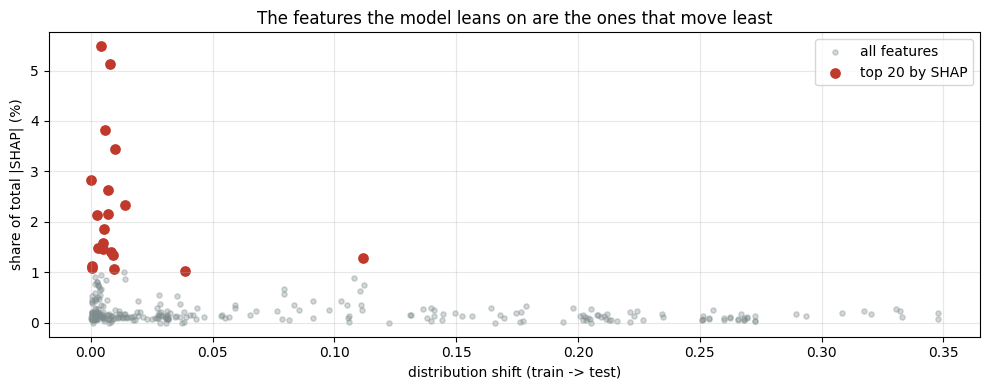

median shift, top 20 by SHAP : 0.0065
median shift, all features   : 0.0275
correlation(importance, shift): -0.211


In [10]:
m = shap.merge(drift[["feature", "shift"]], on="feature", how="inner").dropna(subset=["shift"])
top20 = m.nlargest(20, "share")

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(m["shift"], m["share"] * 100, s=14, alpha=.35, color="#7f8c8d", label="all features")
ax.scatter(top20["shift"], top20["share"] * 100, s=45, color="#c0392b", label="top 20 by SHAP")
ax.set_xlabel("distribution shift (train -> test)")
ax.set_ylabel("share of total |SHAP| (%)")
ax.set_title("The features the model leans on are the ones that move least")
ax.legend()
plt.tight_layout(); plt.show()

print(f"median shift, top 20 by SHAP : {top20['shift'].median():.4f}")
print(f"median shift, all features   : {m['shift'].median():.4f}")
print(f"correlation(importance, shift): {m['share'].corr(m['shift']):+.3f}")

This is the payoff of a decision made early and for a different reason.

Notebook 01 measured that the test split carries ~36% more order events per sample. That is
why the feature layer was built out of **ratios and rates rather than raw counts** — a
defensive choice against a known density difference.

The drift measurement shows that choice worked, and the SHAP measurement shows the model
independently selected those same scale-free quantities as its strongest signals. The
design constraint and the predictive signal pointed the same way.

**The honest caveat:** rate features are still in the set, and they *do* shift — the eight
moderate-shift features are all rates or spreads. They were kept because they carry real
information about activity, but they are the most likely source of degradation on unseen
data, and they are where investigation should start if the leaderboard score comes in below
the hold-out estimate.

---
## Summary

| Question | Answer |
|---|---|
| Why no cross-sample features? | No symbol column exists — each sample is anonymous and self-contained |
| What does "rolling" mean here? | Nested windows inside a sample; 600 s for market, 60 s for order/transaction |
| What does the model use? | Imbalance features, then microprice edge and short-horizon returns |
| Do the features transfer? | 201 of 294 shift negligibly; none shifts "large" |
| What shifts most? | Rates and counts (median 0.176) — the test period is more liquid |
| What shifts least? | Scale-free imbalances (median 0.002–0.007) |
| And those are…? | …exactly the features SHAP ranks highest |